In [1]:
import pandas as pd
import numpy as np


# 파일 경로
file_path = "../data/hn22_all.sas7bdat"

# SAS 파일 읽기
df24 = pd.read_sas(file_path, format="sas7bdat")
df24=df24[['ID','HE_DM_HbA1c','sex','age','edu','ho_incm5','occp','HE_glu','HE_HbA1c','HE_chol','HE_HDL_st2','HE_TG','HE_LDL_drct','BS3_1','BS3_2','BS3_3','BS12_47','BS12_47_1','BS12_47_2','BD1_11','BD2_1','BE3_71','BE3_72','BE3_73','BE3_74','BE3_81','BE3_82','BE3_83','BE3_84','BE3_75','BE3_76','BE3_77','BE3_78','BE3_85','BE3_86','BE3_87','BE3_88','BE3_31','BE3_32','BE3_33','BP16_1','BP1','HE_sbp','HE_wt','HE_ht','HE_wc','HE_BMI','L_BR_FQ','L_LN_FQ','L_DN_FQ','LS_VEG1','LS_VEG2','LS_FRUIT']]
# 데이터 확인
df24_old=df24
print(df24.head())
df24.shape

              ID  HE_DM_HbA1c  sex   age  edu  ho_incm5  occp  HE_glu  \
0  b'YA01220302'          1.0  2.0  56.0  3.0       4.0   7.0    94.0   
1  b'YA01220303'          1.0  1.0  30.0  4.0       4.0   3.0    84.0   
2  b'YA01220304'          1.0  2.0  25.0  4.0       4.0   7.0    87.0   
3  b'YA01236501'          1.0  1.0  66.0  4.0       3.0   7.0    87.0   
4  b'YA01236502'          1.0  2.0  62.0  3.0       3.0   6.0    91.0   

   HE_HbA1c  HE_chol  ...  HE_wt  HE_ht  HE_wc     HE_BMI  L_BR_FQ  L_LN_FQ  \
0       5.6    199.0  ...   60.6  151.2   84.3  26.507517      3.0      1.0   
1       5.3    122.0  ...   82.3  174.1   86.2  27.152029      1.0      1.0   
2       5.0    202.0  ...   59.0  166.4   69.4  21.308131      4.0      1.0   
3       5.2    136.0  ...   67.1  168.7   83.5  23.577207      1.0      1.0   
4       5.6    149.0  ...   53.9  157.1   77.5  21.839183      1.0      1.0   

   L_DN_FQ  LS_VEG1  LS_VEG2  LS_FRUIT  
0      1.0      2.0      2.0       2.0  
1   

(6265, 53)

In [2]:
#흡연 관련 변수 처리

# --------------------------
# 1. 원본 복사 (안전하게 작업)
# --------------------------
df = df24.copy()

# --------------------------
# 2. 무응답 코드 → Na 처리
# --------------------------

# 일반담배
df['BS3_1'] = df['BS3_1'].replace(9, np.nan)
df['BS3_2'] = df['BS3_2'].replace([88, 99], np.nan)
df['BS3_3'] = df['BS3_3'].replace([8888, 9999], np.nan)

# 궐련형 전자담배
df['BS12_47'] = df['BS12_47'].replace(9, np.nan)
df['BS12_47_1'] = df['BS12_47_1'].replace([88, 99], np.nan)
df['BS12_47_2'] = df['BS12_47_2'].replace([8888, 9999], np.nan)

# --------------------------
# 3. 일반담배 주간 흡연량 계산
# --------------------------

cig_weekly = pd.Series(np.nan, index=df.index)

# 3-1 매일피움
mask_daily = df['BS3_1'] == 1
cig_weekly[mask_daily] = df.loc[mask_daily, 'BS3_2'] * 7

# 3-2 가끔피움
mask_occasional = df['BS3_1'] == 2
cig_weekly[mask_occasional] = (
    df.loc[mask_occasional, 'BS3_2'] *
    df.loc[mask_occasional, 'BS3_3'] / 30 * 7
)

# 3-3 현재 안 피움 (3,8) → 0
mask_non = df['BS3_1'].isin([3, 8])
cig_weekly[mask_non] = 0

# --------------------------
# 4. 궐련형 전자담배 주간 흡연량 계산
# --------------------------

htp_weekly = pd.Series(np.nan, index=df.index)

mask_daily_htp = df['BS12_47'] == 1
htp_weekly[mask_daily_htp] = df.loc[mask_daily_htp, 'BS12_47_1'] * 7

mask_occasional_htp = df['BS12_47'] == 2
htp_weekly[mask_occasional_htp] = (
    df.loc[mask_occasional_htp, 'BS12_47_1'] *
    df.loc[mask_occasional_htp, 'BS12_47_2'] / 30 * 7
)

mask_non_htp = df['BS12_47'].isin([3, 8])
htp_weekly[mask_non_htp] = 0

# --------------------------
# 5. 최종 주간 평균 흡연량
# --------------------------
df24['week_avg_smk'] = cig_weekly + htp_weekly


In [3]:
df24.loc[df24['week_avg_smk']==420,'BS3_2']

5595    60.0
Name: BS3_2, dtype: float64

In [4]:
cols_to_drop = [
    'BS3_1', 'BS3_2', 'BS3_3',
    'BS12_47', 'BS12_47_1', 'BS12_47_2'
]

df24 = df24.drop(columns=cols_to_drop)
df24.columns

Index(['ID', 'HE_DM_HbA1c', 'sex', 'age', 'edu', 'ho_incm5', 'occp', 'HE_glu',
       'HE_HbA1c', 'HE_chol', 'HE_HDL_st2', 'HE_TG', 'HE_LDL_drct', 'BD1_11',
       'BD2_1', 'BE3_71', 'BE3_72', 'BE3_73', 'BE3_74', 'BE3_81', 'BE3_82',
       'BE3_83', 'BE3_84', 'BE3_75', 'BE3_76', 'BE3_77', 'BE3_78', 'BE3_85',
       'BE3_86', 'BE3_87', 'BE3_88', 'BE3_31', 'BE3_32', 'BE3_33', 'BP16_1',
       'BP1', 'HE_sbp', 'HE_wt', 'HE_ht', 'HE_wc', 'HE_BMI', 'L_BR_FQ',
       'L_LN_FQ', 'L_DN_FQ', 'LS_VEG1', 'LS_VEG2', 'LS_FRUIT', 'week_avg_smk'],
      dtype='object')

In [5]:
#음주 관련 변수 처리

df = df24.copy()

# --------------------------
# 1. 무응답 → Na 처리
# --------------------------
df['BD1_11'] = df['BD1_11'].replace(9, np.nan)
df['BD2_1'] = df['BD2_1'].replace(9, np.nan)

# --------------------------
# 2. 빈도 → 주간 횟수 변환
# --------------------------
freq_map = {
    1: 0,
    2: 0.125,   # 월1회 미만 (월0.5회 가정)
    3: 0.25,    # 월1회
    4: 0.75,    # 월3회 평균
    5: 2.5,     # 주2-3회
    6: 4,       # 주4회 이상
    8: 0        # 비해당
}

df['weekly_freq'] = df['BD1_11'].map(freq_map)

# --------------------------
# 3. 1회 음주량 → 잔 수 변환
# --------------------------
amount_map = {
    1: 1.5,
    2: 3.5,
    3: 5.5,
    4: 8,
    5: 10,
    8: 0
}

df['drink_per_session'] = df['BD2_1'].map(amount_map)

# --------------------------
# 4. 주간 평균 음주량 계산
# --------------------------
df24['week_avg_alcohol'] = df['weekly_freq'] * df['drink_per_session']


In [6]:
cols_to_drop = [
    'BD1_11', 'BD2_1'
]

df24 = df24.drop(columns=cols_to_drop)
df24.columns

Index(['ID', 'HE_DM_HbA1c', 'sex', 'age', 'edu', 'ho_incm5', 'occp', 'HE_glu',
       'HE_HbA1c', 'HE_chol', 'HE_HDL_st2', 'HE_TG', 'HE_LDL_drct', 'BE3_71',
       'BE3_72', 'BE3_73', 'BE3_74', 'BE3_81', 'BE3_82', 'BE3_83', 'BE3_84',
       'BE3_75', 'BE3_76', 'BE3_77', 'BE3_78', 'BE3_85', 'BE3_86', 'BE3_87',
       'BE3_88', 'BE3_31', 'BE3_32', 'BE3_33', 'BP16_1', 'BP1', 'HE_sbp',
       'HE_wt', 'HE_ht', 'HE_wc', 'HE_BMI', 'L_BR_FQ', 'L_LN_FQ', 'L_DN_FQ',
       'LS_VEG1', 'LS_VEG2', 'LS_FRUIT', 'week_avg_smk', 'week_avg_alcohol'],
      dtype='object')

In [7]:
cols_to_drop = [
    'BE3_71','BE3_72','BE3_73','BE3_74','BE3_81','BE3_82','BE3_83','BE3_84'
]

df24 = df24.drop(columns=cols_to_drop)
df24.columns

Index(['ID', 'HE_DM_HbA1c', 'sex', 'age', 'edu', 'ho_incm5', 'occp', 'HE_glu',
       'HE_HbA1c', 'HE_chol', 'HE_HDL_st2', 'HE_TG', 'HE_LDL_drct', 'BE3_75',
       'BE3_76', 'BE3_77', 'BE3_78', 'BE3_85', 'BE3_86', 'BE3_87', 'BE3_88',
       'BE3_31', 'BE3_32', 'BE3_33', 'BP16_1', 'BP1', 'HE_sbp', 'HE_wt',
       'HE_ht', 'HE_wc', 'HE_BMI', 'L_BR_FQ', 'L_LN_FQ', 'L_DN_FQ', 'LS_VEG1',
       'LS_VEG2', 'LS_FRUIT', 'week_avg_smk', 'week_avg_alcohol'],
      dtype='object')

In [8]:
#여가 mvpa 변수 처리

df = df24.copy()

# --------------------------
# 1. 무응답 → Na 처리
# --------------------------

# 여가 고강도
df['BE3_75'] = df['BE3_75'].replace(9, np.nan)
df['BE3_76'] = df['BE3_76'].replace([8, 9], np.nan)
df['BE3_77'] = df['BE3_77'].replace([88, 99], np.nan)
df['BE3_78'] = df['BE3_78'].replace([88, 99], np.nan)

# 여가 중강도
df['BE3_85'] = df['BE3_85'].replace(9, np.nan)
df['BE3_86'] = df['BE3_86'].replace([8, 9], np.nan)
df['BE3_87'] = df['BE3_87'].replace([88, 99], np.nan)
df['BE3_88'] = df['BE3_88'].replace([88, 99], np.nan)

# --------------------------
# 2. 여가 고강도 주간 분 계산
# --------------------------

leisure_vig = pd.Series(np.nan, index=df.index)

# 아니오/비해당 → 0
mask_vig_no = df['BE3_75'].isin([2, 8])
leisure_vig[mask_vig_no] = 0

# 예 → 계산
mask_vig_yes = df['BE3_75'] == 1

vig_minutes_per_day = (
    df.loc[mask_vig_yes, 'BE3_77'] * 60 +
    df.loc[mask_vig_yes, 'BE3_78']
)

leisure_vig[mask_vig_yes] = (
    vig_minutes_per_day *
    df.loc[mask_vig_yes, 'BE3_76']
)

# --------------------------
# 3. 여가 중강도 주간 분 계산
# --------------------------

leisure_mod = pd.Series(np.nan, index=df.index)

mask_mod_no = df['BE3_85'].isin([2, 8])
leisure_mod[mask_mod_no] = 0

mask_mod_yes = df['BE3_85'] == 1

mod_minutes_per_day = (
    df.loc[mask_mod_yes, 'BE3_87'] * 60 +
    df.loc[mask_mod_yes, 'BE3_88']
)

leisure_mod[mask_mod_yes] = (
    mod_minutes_per_day *
    df.loc[mask_mod_yes, 'BE3_86']
)

# --------------------------
# 4. 최종 여가 MVPA (분)
# --------------------------

df24['week_mvpa_play'] = leisure_vig + leisure_mod


In [9]:
cols_to_drop = [
    'BE3_75','BE3_76','BE3_77','BE3_78','BE3_85','BE3_86','BE3_87','BE3_88'
]

df24 = df24.drop(columns=cols_to_drop)
df24.columns

Index(['ID', 'HE_DM_HbA1c', 'sex', 'age', 'edu', 'ho_incm5', 'occp', 'HE_glu',
       'HE_HbA1c', 'HE_chol', 'HE_HDL_st2', 'HE_TG', 'HE_LDL_drct', 'BE3_31',
       'BE3_32', 'BE3_33', 'BP16_1', 'BP1', 'HE_sbp', 'HE_wt', 'HE_ht',
       'HE_wc', 'HE_BMI', 'L_BR_FQ', 'L_LN_FQ', 'L_DN_FQ', 'LS_VEG1',
       'LS_VEG2', 'LS_FRUIT', 'week_avg_smk', 'week_avg_alcohol',
       'week_mvpa_play'],
      dtype='object')

In [10]:
#걷기 시간 변수 처리
df = df24.copy()

# --------------------------
# 1. 무응답 → Na 처리
# --------------------------

df['BE3_31'] = df['BE3_31'].replace(99, np.nan)
df['BE3_32'] = df['BE3_32'].replace([88, 99], np.nan)
df['BE3_33'] = df['BE3_33'].replace([88, 99], np.nan)

# --------------------------
# 2. 주간 걷기 일수 계산
# --------------------------

walking_days = pd.Series(np.nan, index=df.index)

# 전혀 안 함(1) 또는 비해당(88) → 0
mask_no_walk = df['BE3_31'].isin([1, 88])
walking_days[mask_no_walk] = 0

# 2~8 → 실제 일수
mask_walk = df['BE3_31'].between(2, 8)
walking_days.loc[mask_walk] = df.loc[mask_walk, 'BE3_31'] - 1

# --------------------------
# 3. 하루 걷기 분 계산
# --------------------------

walking_minutes_per_day = (
    df['BE3_32'] * 60 +
    df['BE3_33']
)

# --------------------------
# 4. 주간 걷기 총 분 계산
# --------------------------

week_walk= walking_days * walking_minutes_per_day

week_walk.loc[mask_no_walk] = 0

df24['week_walk'] =week_walk


In [11]:
cols_to_drop = [
    'BE3_31','BE3_32','BE3_33'
]

df24 = df24.drop(columns=cols_to_drop)
df24.columns

Index(['ID', 'HE_DM_HbA1c', 'sex', 'age', 'edu', 'ho_incm5', 'occp', 'HE_glu',
       'HE_HbA1c', 'HE_chol', 'HE_HDL_st2', 'HE_TG', 'HE_LDL_drct', 'BP16_1',
       'BP1', 'HE_sbp', 'HE_wt', 'HE_ht', 'HE_wc', 'HE_BMI', 'L_BR_FQ',
       'L_LN_FQ', 'L_DN_FQ', 'LS_VEG1', 'LS_VEG2', 'LS_FRUIT', 'week_avg_smk',
       'week_avg_alcohol', 'week_mvpa_play', 'week_walk'],
      dtype='object')

In [12]:
#수면시간 변수 처리
df = df24.copy()

# --------------------------
# 1. 무응답 / 비해당 → Na 처리
# --------------------------

cols = ['BP16_1']

for col in cols:
    df[col] = df[col].replace([88, 99], np.nan)

# --------------------------
# 2. 분 단위로 변환
# --------------------------

sleep_min = df['BP16_1'] * 60 


df24['week_sleep'] = sleep_min


In [13]:
df24['week_sleep'].describe()

count    5425.000000
mean      405.378802
std        77.450439
min       120.000000
25%       360.000000
50%       420.000000
75%       480.000000
max       840.000000
Name: week_sleep, dtype: float64

In [14]:
cols_to_drop = [
    'BP16_1'
]

df24 = df24.drop(columns=cols_to_drop)
df24.columns

Index(['ID', 'HE_DM_HbA1c', 'sex', 'age', 'edu', 'ho_incm5', 'occp', 'HE_glu',
       'HE_HbA1c', 'HE_chol', 'HE_HDL_st2', 'HE_TG', 'HE_LDL_drct', 'BP1',
       'HE_sbp', 'HE_wt', 'HE_ht', 'HE_wc', 'HE_BMI', 'L_BR_FQ', 'L_LN_FQ',
       'L_DN_FQ', 'LS_VEG1', 'LS_VEG2', 'LS_FRUIT', 'week_avg_smk',
       'week_avg_alcohol', 'week_mvpa_play', 'week_walk', 'week_sleep'],
      dtype='object')

In [15]:
import numpy as np

stress_map = {
    1: 4,
    2: 3,
    3: 2,
    4: 1,
}

df24['stress'] = df24['BP1'].map(stress_map)

# 9 (무응답)는 자동으로 Na 처리됨
df24.loc[df24['BP1'] == 9, 'stress'] = np.nan

cols_to_drop = [
    'BP1'
]

df24 = df24.drop(columns=cols_to_drop)
df24.columns


Index(['ID', 'HE_DM_HbA1c', 'sex', 'age', 'edu', 'ho_incm5', 'occp', 'HE_glu',
       'HE_HbA1c', 'HE_chol', 'HE_HDL_st2', 'HE_TG', 'HE_LDL_drct', 'HE_sbp',
       'HE_wt', 'HE_ht', 'HE_wc', 'HE_BMI', 'L_BR_FQ', 'L_LN_FQ', 'L_DN_FQ',
       'LS_VEG1', 'LS_VEG2', 'LS_FRUIT', 'week_avg_smk', 'week_avg_alcohol',
       'week_mvpa_play', 'week_walk', 'week_sleep', 'stress'],
      dtype='object')

In [16]:
# 주별 식사빈도에 대한 변수 처리
meal_map = {
    1: 6,      # 5~7회 → 중앙값 6
    2: 3.5,    # 3~4회 → 중앙값 3.5
    3: 1.5,    # 1~2회 → 중앙값 1.5
    4: 0       # 거의 안함
}

# 아침
df24['week_break'] = df24['L_BR_FQ'].map(meal_map)
df24.loc[df24['L_BR_FQ'] == 9, 'week_break'] = np.nan

# 점심
df24['week_lunch'] = df24['L_LN_FQ'].map(meal_map)
df24.loc[df24['L_LN_FQ'] == 9, 'week_lunch'] = np.nan

# 저녁
df24['week_dinner'] = df24['L_DN_FQ'].map(meal_map)
df24.loc[df24['L_DN_FQ'] == 9, 'week_dinner'] = np.nan

cols_to_drop = [
    'L_BR_FQ','L_LN_FQ','L_DN_FQ','ID'
]

df24 = df24.drop(columns=cols_to_drop)
df24.columns

Index(['HE_DM_HbA1c', 'sex', 'age', 'edu', 'ho_incm5', 'occp', 'HE_glu',
       'HE_HbA1c', 'HE_chol', 'HE_HDL_st2', 'HE_TG', 'HE_LDL_drct', 'HE_sbp',
       'HE_wt', 'HE_ht', 'HE_wc', 'HE_BMI', 'LS_VEG1', 'LS_VEG2', 'LS_FRUIT',
       'week_avg_smk', 'week_avg_alcohol', 'week_mvpa_play', 'week_walk',
       'week_sleep', 'stress', 'week_break', 'week_lunch', 'week_dinner'],
      dtype='object')

In [17]:
#음식섭취 변수 처리
food_freq_map = {
    1: 21,     # 하루 3회 이상
    2: 14,     # 하루 2회
    3: 7,      # 하루 1회
    4: 5.5,    # 주 5-6회
    5: 3,      # 주 2-4회
    6: 1,      # 주 1회
    7: 0.625,  # 월 2-3회
    8: 0.25,   # 월 1회
    9: 0       # 거의 안함
}

# 채소 (김치 포함)
df24['weekly_veg1_freq'] = df24['LS_VEG1'].map(food_freq_map)
df24.loc[df24['LS_VEG1'] == 99, 'weekly_veg1_freq'] = np.nan

# 채소 (김치 제외)
df24['weekly_veg2_freq'] = df24['LS_VEG2'].map(food_freq_map)
df24.loc[df24['LS_VEG2'] == 99, 'weekly_veg2_freq'] = np.nan

# 과일
df24['weekly_fruit_freq'] = df24['LS_FRUIT'].map(food_freq_map)
df24.loc[df24['LS_FRUIT'] == 99, 'weekly_fruit_freq'] = np.nan

cols_to_drop = [
    'LS_VEG1','LS_VEG2','LS_FRUIT'
]

df24 = df24.drop(columns=cols_to_drop)
df24.columns



Index(['HE_DM_HbA1c', 'sex', 'age', 'edu', 'ho_incm5', 'occp', 'HE_glu',
       'HE_HbA1c', 'HE_chol', 'HE_HDL_st2', 'HE_TG', 'HE_LDL_drct', 'HE_sbp',
       'HE_wt', 'HE_ht', 'HE_wc', 'HE_BMI', 'week_avg_smk', 'week_avg_alcohol',
       'week_mvpa_play', 'week_walk', 'week_sleep', 'stress', 'week_break',
       'week_lunch', 'week_dinner', 'weekly_veg1_freq', 'weekly_veg2_freq',
       'weekly_fruit_freq'],
      dtype='object')

In [18]:
col_map = {
    'ID': 'id',
    'HE_DM_HbA1c': 'dm',
    'sex': 'sex',
    'age': 'age',
    'edu': 'edu',
    'ho_incm5': 'income',
    'occp': 'job',

    'HE_glu': 'glu',
    'HE_HbA1c': 'hba1c',
    'HE_chol': 'chol',
    'HE_HDL_st2': 'hdl',
    'HE_TG': 'tg',
    'HE_LDL_drct': 'ldl',

    'HE_sbp': 'sbp',
    'HE_wt': 'wt',
    'HE_ht': 'ht',
    'HE_wc': 'wc',
    'HE_BMI': 'bmi',

    'week_avg_smk': 'wk_smk',
    'week_avg_alcohol': 'wk_alc',
    'week_mvpa_play': 'wk_mvpa_play',
    'week_walk': 'wk_walk',
    'week_sleep': 'wk_sleep',

    'stress': 'stress',

    'week_break': 'wk_break',
    'week_lunch': 'wk_lunch',
    'week_dinner': 'wk_dinner',

    'weekly_veg1_freq': 'wk_veg1',
    'weekly_veg2_freq': 'wk_veg2',
    'weekly_fruit_freq': 'wk_fruit'
}

# 적용
df24 = df24.rename(columns=col_map)

In [19]:
df24.columns

Index(['dm', 'sex', 'age', 'edu', 'income', 'job', 'glu', 'hba1c', 'chol',
       'hdl', 'tg', 'ldl', 'sbp', 'wt', 'ht', 'wc', 'bmi', 'wk_smk', 'wk_alc',
       'wk_mvpa_play', 'wk_walk', 'wk_sleep', 'stress', 'wk_break', 'wk_lunch',
       'wk_dinner', 'wk_veg1', 'wk_veg2', 'wk_fruit'],
      dtype='object')

In [20]:
df24.shape

(6265, 29)

In [21]:
df24_2=df24.loc[df24['age']>=20]
print(df24_2.shape)

(5279, 29)


In [22]:
df24_3=df24_2.dropna()
print(df24_3.shape)

(4076, 29)


In [23]:
df24_3.columns

Index(['dm', 'sex', 'age', 'edu', 'income', 'job', 'glu', 'hba1c', 'chol',
       'hdl', 'tg', 'ldl', 'sbp', 'wt', 'ht', 'wc', 'bmi', 'wk_smk', 'wk_alc',
       'wk_mvpa_play', 'wk_walk', 'wk_sleep', 'stress', 'wk_break', 'wk_lunch',
       'wk_dinner', 'wk_veg1', 'wk_veg2', 'wk_fruit'],
      dtype='object')

In [24]:
df24_3['dm'] = df24_3['dm'].map({1: 0, 2: 1, 3: 2})
df24_3['dm'].value_counts()

C:\Users\cmc\AppData\Local\Temp\ipykernel_40728\2866111520.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df24_3['dm'] = df24_3['dm'].map({1: 0, 2: 1, 3: 2})


dm
0    2126
1    1362
2     588
Name: count, dtype: int64

In [25]:
df24.nunique()

dm                 3
sex                2
age               80
edu                4
income             5
job                7
glu              170
hba1c             76
chol             245
hdl              103
tg               425
ldl              216
sbp              211
wt               896
ht               785
wc               645
bmi             5988
wk_smk            98
wk_alc            25
wk_mvpa_play      93
wk_walk           93
wk_sleep          12
stress             4
wk_break           4
wk_lunch           4
wk_dinner          4
wk_veg1            8
wk_veg2            9
wk_fruit           9
dtype: int64

<Axes: >

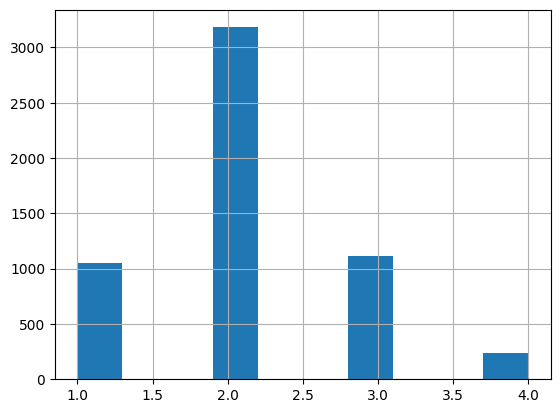

In [26]:
df24['stress'].hist()

In [27]:
df24_3.to_pickle("../df22.pkl")
